# Análisis Exploratorio de Datos (EDA) - Vulnerability Fix Dataset

## Objetivo
Realizar un análisis exploratorio completo del dataset de vulnerabilidades de código Java para determinar su aptitud en la construcción de un modelo de clasificación binaria (SEGURO / VULNERABLE).

### Contexto del Proyecto
- **Lenguaje analizado**: Java
- **Objetivo**: Clasificación binaria de vulnerabilidades mediante ML clásico
- **Dataset**: Vulnerability Fix Dataset de Kaggle
- **Requisitos**: Análisis sin modificación de datos, preparación para pipeline CI/CD

---

## 1. Importar Bibliotecas Requeridas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configurar opciones de visualización de pandas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', None)

# Configurar matplotlib para mejor visualización
plt.style.use('default')
print("✓ Bibliotecas importadas correctamente")
print(f"  - pandas versión: {pd.__version__}")
print(f"  - numpy versión: {np.__version__}")
print(f"  - matplotlib versión: {plt.matplotlib.__version__}")

✓ Bibliotecas importadas correctamente
  - pandas versión: 2.3.1
  - numpy versión: 2.4.2
  - matplotlib versión: 3.10.8


## 2. Cargar el Dataset

In [4]:
import os
from pathlib import Path

# Definir ruta del dataset
ruta_proyecto = Path('../data/raw/vulnerability_fix_dataset.csv')

# Verificar que el archivo existe
if ruta_proyecto.exists():
    print(f"✓ Archivo encontrado: {ruta_proyecto}")
    # Cargar el dataset
    df = pd.read_csv(ruta_proyecto, encoding='utf-8', on_bad_lines='skip')
    print(f"✓ Dataset cargado exitosamente")
else:
    print(f"✗ Archivo no encontrado en: {ruta_proyecto}")
    print(f"  Directorio actual: {os.getcwd()}")
    print(f"  Archivos disponibles en data/raw/:")
    for file in Path('../data/raw/').iterdir():
        print(f"    - {file.name}")

✓ Archivo encontrado: ..\data\raw\vulnerability_fix_dataset.csv
✓ Dataset cargado exitosamente


## 3. Información General del Dataset

In [5]:
# Información básica del dataset
print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)

print(f"\n📊 DIMENSIONES:")
print(f"  • Número de filas: {df.shape[0]:,}")
print(f"  • Número de columnas: {df.shape[1]}")

print(f"\n📋 NOMBRES DE COLUMNAS:")
for idx, col in enumerate(df.columns, 1):
    print(f"  {idx}. {col}")

print(f"\n📈 PRIMERAS 3 FILAS:")
print(df.head(3))

INFORMACIÓN GENERAL DEL DATASET

📊 DIMENSIONES:
  • Número de filas: 35,000
  • Número de columnas: 3

📋 NOMBRES DE COLUMNAS:
  1. vulnerability_type
  2. vulnerable_code
  3. fixed_code

📈 PRIMERAS 3 FILAS:
  vulnerability_type  \
0      SQL Injection   
1      SQL Injection   
2      SQL Injection   

                                                                                       vulnerable_code  \
0  import java.sql.*;\n\npublic class SQLInjectionVulnerable {\n    public static void main(String[...   
1  import java.sql.*;\n\npublic class VulnerableSQLInjection {\n    public static void main(String[...   
2  import java.sql.*;\n\npublic class SQLInjectionExample {\n\n    public static void main(String[]...   

                                                                                            fixed_code  
0  import java.sql.*;\n\npublic class SQLInjectionSecure {\n    public static void main(String[] ar...  
1  import java.sql.*;\n\npublic class SecureSQLInjection {\n

## 4. Análisis de Tipos de Datos y Valores Nulos

TIPOS DE DATOS Y VALORES NULOS

🔍 TIPOS DE DATOS:
vulnerability_type    object
vulnerable_code       object
fixed_code            object
dtype: object

❌ VALORES NULOS POR COLUMNA:
           Columna  Valores Nulos  Porcentaje (%)
vulnerability_type              0             0.0
   vulnerable_code              0             0.0
        fixed_code              0             0.0


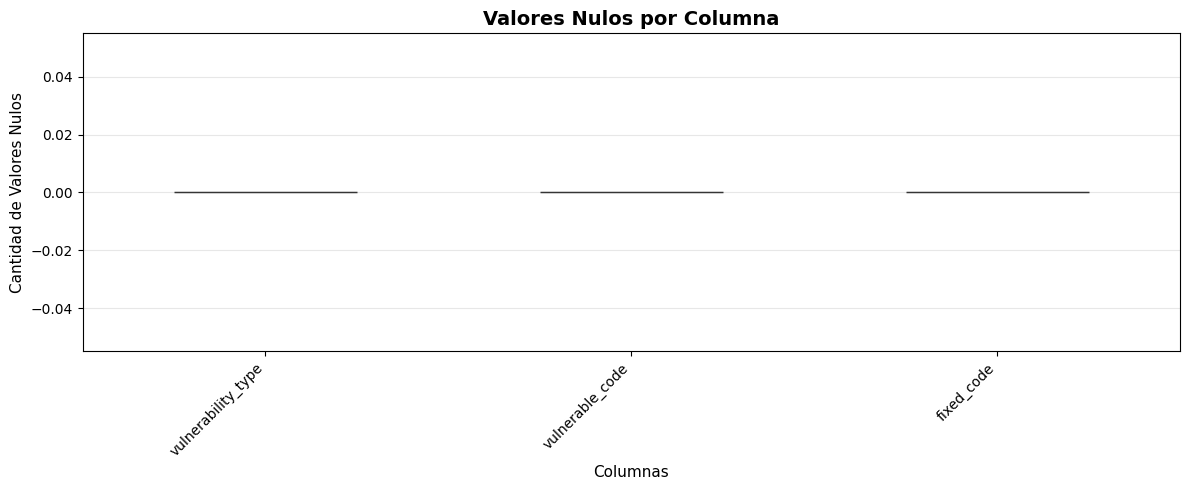


📊 RESUMEN: Total de valores nulos en el dataset: 0


In [6]:
print("=" * 80)
print("TIPOS DE DATOS Y VALORES NULOS")
print("=" * 80)

# Tipos de datos
print(f"\n🔍 TIPOS DE DATOS:")
print(df.dtypes)

# Valores nulos
print(f"\n❌ VALORES NULOS POR COLUMNA:")
valores_nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
info_nulos = pd.DataFrame({
    'Columna': df.columns,
    'Valores Nulos': valores_nulos.values,
    'Porcentaje (%)': porcentaje_nulos.values
})
print(info_nulos.to_string(index=False))

# Visualización de valores nulos
fig, ax = plt.subplots(figsize=(12, 5))
valores_nulos.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('Valores Nulos por Columna', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad de Valores Nulos', fontsize=11)
ax.set_xlabel('Columnas', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen
total_nulos = df.isnull().sum().sum()
print(f"\n📊 RESUMEN: Total de valores nulos en el dataset: {total_nulos}")

## 5. Detección de Registros Duplicados

In [7]:
print("=" * 80)
print("DETECCIÓN DE REGISTROS DUPLICADOS")
print("=" * 80)

# Duplicados completos
duplicados_totales = df.duplicated().sum()
print(f"\n🔄 DUPLICADOS COMPLETOS:")
print(f"  • Registros completamente duplicados: {duplicados_totales}")
print(f"  • Porcentaje: {(duplicados_totales / len(df)) * 100:.2f}%")

# Duplicados por subconjunto de columnas (si aplica)
if len(df.columns) > 2:
    print(f"\n🔍 ANÁLISIS DE DUPLICADOS POR COLUMNAS CLAVE:")
    # Intentar identificar columnas que podrían ser identificadores únicos
    for col in df.columns:
        duplicados_col = df.duplicated(subset=[col]).sum()
        if duplicados_col > 0:
            print(f"  • Duplicados en '{col}': {duplicados_col}")

# Mostrar ejemplos de duplicados si existen
if duplicados_totales > 0:
    print(f"\n📌 EJEMPLOS DE REGISTROS DUPLICADOS (primeros 3):")
    duplicados_mask = df.duplicated(keep=False)
    ejemplos = df[duplicados_mask].head(3)
    print(ejemplos)

DETECCIÓN DE REGISTROS DUPLICADOS

🔄 DUPLICADOS COMPLETOS:
  • Registros completamente duplicados: 2517
  • Porcentaje: 7.19%

🔍 ANÁLISIS DE DUPLICADOS POR COLUMNAS CLAVE:
  • Duplicados en 'vulnerability_type': 34994
  • Duplicados en 'vulnerable_code': 5398
  • Duplicados en 'fixed_code': 2911

📌 EJEMPLOS DE REGISTROS DUPLICADOS (primeros 3):
    vulnerability_type  \
126      SQL Injection   
180      SQL Injection   
288      SQL Injection   

                                                                                         vulnerable_code  \
126  import java.sql.*;\n\npublic class SQLInjectionExample {\n    public static void main(String[] a...   
180  import java.sql.*;\n\npublic class SQLInjectionExample {\n\n    public static void main(String[]...   
288  import java.sql.*;\n\npublic class SQLInjectionExample {\n    public static void main(String[] a...   

                                                                                              fixed_code  
126  imp

## 6. Análisis de Distribución de Vulnerabilidades

ANÁLISIS DE DISTRIBUCIÓN DE VULNERABILIDADES

📊 DISTRIBUCIÓN EN COLUMNA 'vulnerability_type':
  Total de categorías: 6

  Conteo por categoría:
    • Cross-Site Scripting (XSS): 9,377 (26.79%)
    • SQL Injection: 7,297 (20.85%)
    • Command Injection: 6,947 (19.85%)
    • Path Traversal: 6,500 (18.57%)
    • Buffer Overflow: 3,157 (9.02%)
    • Insecure Deserialization: 1,722 (4.92%)


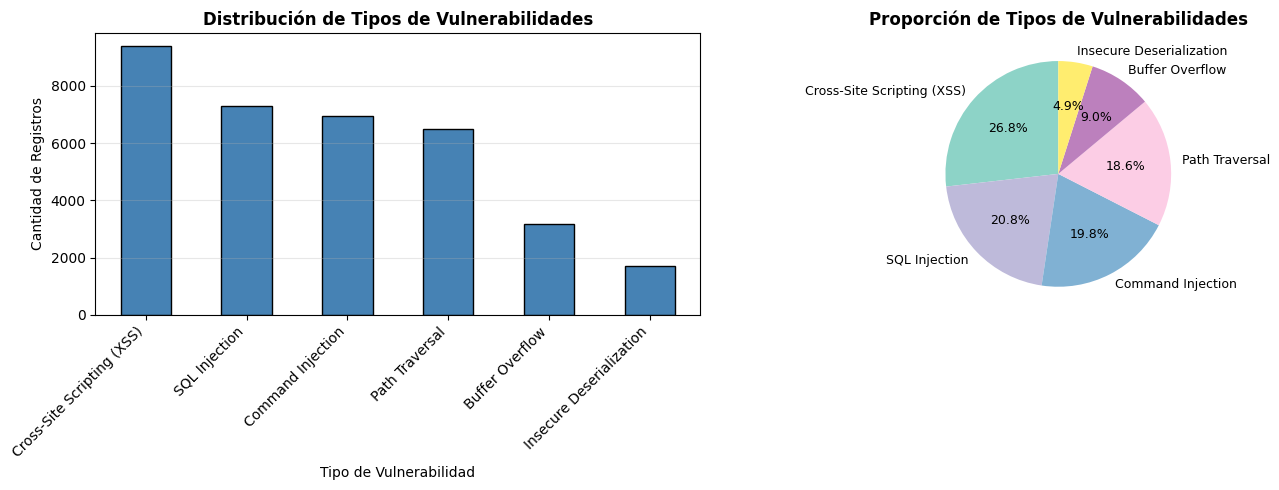

In [8]:
print("=" * 80)
print("ANÁLISIS DE DISTRIBUCIÓN DE VULNERABILIDADES")
print("=" * 80)

# Identificar columnas potenciales de etiqueta/clase
columnas_potenciales = [col for col in df.columns if 'label' in col.lower() or 'type' in col.lower() or 'class' in col.lower() or 'vulnerability' in col.lower()]

if columnas_potenciales:
    for col_label in columnas_potenciales:
        print(f"\n📊 DISTRIBUCIÓN EN COLUMNA '{col_label}':")
        distribucion = df[col_label].value_counts()
        porcentajes = (df[col_label].value_counts(normalize=True) * 100).round(2)
        
        print(f"  Total de categorías: {len(distribucion)}")
        print(f"\n  Conteo por categoría:")
        for categoria, conteo in distribucion.items():
            print(f"    • {categoria}: {conteo:,} ({porcentajes[categoria]:.2f}%)")
        
        # Visualización
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Gráfico de barras
        distribucion.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
        ax1.set_title(f'Distribución de Tipos de Vulnerabilidades', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Cantidad de Registros', fontsize=10)
        ax1.set_xlabel('Tipo de Vulnerabilidad', fontsize=10)
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax1.grid(axis='y', alpha=0.3)
        
        # Gráfico de pastel
        colores = plt.cm.Set3(np.linspace(0, 1, len(distribucion)))
        ax2.pie(distribucion.values, labels=distribucion.index, autopct='%1.1f%%',
                colors=colores, startangle=90, textprops={'fontsize': 9})
        ax2.set_title(f'Proporción de Tipos de Vulnerabilidades', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
else:
    print("\n⚠️  No se encontraron columnas de etiqueta/vulnerabilidad obvias.")
    print(f"    Nombres de columnas disponibles: {list(df.columns)}")

## 7. Ejemplos Aleatorios de Registros

In [9]:
print("=" * 80)
print("EJEMPLOS ALEATORIOS DE REGISTROS")
print("=" * 80)

# Seleccionar registros aleatorios
np.random.seed(42)
cantidad_ejemplos = min(5, len(df))
indices_aleatorios = np.random.choice(df.index, size=cantidad_ejemplos, replace=False)

print(f"\n📋 Mostrando {cantidad_ejemplos} registros aleatorios:\n")
for idx, fila_idx in enumerate(indices_aleatorios, 1):
    print(f"\n{'='*60}")
    print(f"Registro #{idx} (Índice: {fila_idx})")
    print(f"{'='*60}")
    fila = df.loc[fila_idx]
    for col, valor in fila.items():
        # Truncar valores largos para mejor legibilidad
        if isinstance(valor, str) and len(valor) > 150:
            print(f"{col}:")
            print(f"  {valor[:150]}...")
        else:
            print(f"{col}: {valor}")
    print()

EJEMPLOS ALEATORIOS DE REGISTROS

📋 Mostrando 5 registros aleatorios:


Registro #1 (Índice: 17813)
vulnerability_type: Command Injection
vulnerable_code:
  import java.io.BufferedReader;
import java.io.IOException;
import java.io.InputStreamReader;

public class CommandInjectionVulnerability {

    public...
fixed_code:
  import java.io.BufferedReader;
import java.io.IOException;
import java.io.InputStreamReader;

public class CommandInjectionFixed {

    public static ...


Registro #2 (Índice: 6857)
vulnerability_type: Cross-Site Scripting (XSS)
vulnerable_code:
  import java.io.IOException;
import javax.servlet.ServletException;
import javax.servlet.http.HttpServlet;
import javax.servlet.http.HttpServletRequest...
fixed_code:
  import java.io.IOException;
import javax.servlet.ServletException;
import javax.servlet.http.HttpServlet;
import javax.servlet.http.HttpServletRequest...


Registro #3 (Índice: 7672)
vulnerability_type: SQL Injection
vulnerable_code:
  import java.sql.*;

pu

## 8. Análisis de Longitud de Código

ANÁLISIS DE LONGITUD DE CÓDIGO

📏 ANÁLISIS DE LONGITUD PARA 'vulnerable_code':
  • Longitud mínima: 22 caracteres
  • Longitud máxima: 1,517 caracteres
  • Longitud promedio: 678.91 caracteres
  • Longitud mediana: 744.00 caracteres
  • Desv. estándar: 259.04
  • Percentil 25%: 541.00
  • Percentil 75%: 849.00

📏 ANÁLISIS DE LONGITUD PARA 'fixed_code':
  • Longitud mínima: 21 caracteres
  • Longitud máxima: 1,666 caracteres
  • Longitud promedio: 947.98 caracteres
  • Longitud mediana: 930.00 caracteres
  • Desv. estándar: 413.47
  • Percentil 25%: 697.00
  • Percentil 75%: 1,343.00


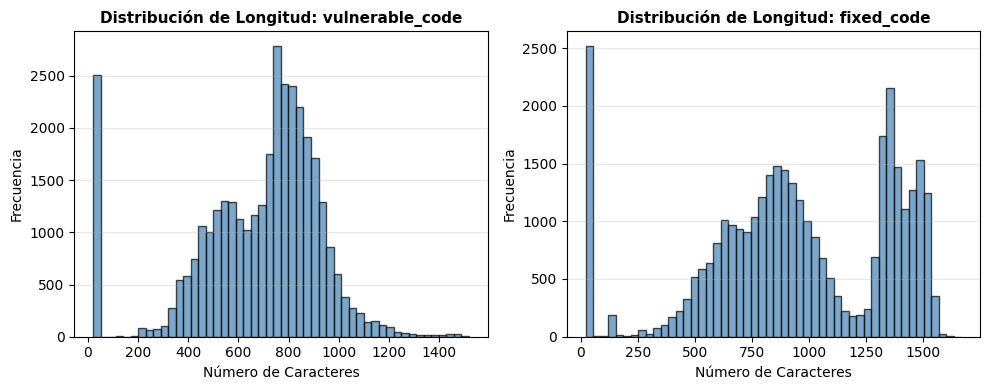

In [10]:
print("=" * 80)
print("ANÁLISIS DE LONGITUD DE CÓDIGO")
print("=" * 80)

# Identificar columnas de código
columnas_codigo = [col for col in df.columns if 'code' in col.lower() or 'source' in col.lower() or 'buggy' in col.lower() or 'fix' in col.lower()]

if columnas_codigo:
    for col in columnas_codigo:
        # Calcular longitudes
        longitudes = df[col].astype(str).str.len()
        
        print(f"\n📏 ANÁLISIS DE LONGITUD PARA '{col}':")
        print(f"  • Longitud mínima: {longitudes.min():,} caracteres")
        print(f"  • Longitud máxima: {longitudes.max():,} caracteres")
        print(f"  • Longitud promedio: {longitudes.mean():,.2f} caracteres")
        print(f"  • Longitud mediana: {longitudes.median():,.2f} caracteres")
        print(f"  • Desv. estándar: {longitudes.std():,.2f}")
        print(f"  • Percentil 25%: {longitudes.quantile(0.25):,.2f}")
        print(f"  • Percentil 75%: {longitudes.quantile(0.75):,.2f}")
    
    # Visualización comparativa si hay al menos 2 columnas de código
    if len(columnas_codigo) >= 2:
        fig, axes = plt.subplots(1, len(columnas_codigo), figsize=(5*len(columnas_codigo), 4))
        if len(columnas_codigo) == 1:
            axes = [axes]
        
        for ax, col in zip(axes, columnas_codigo):
            longitudes = df[col].astype(str).str.len()
            ax.hist(longitudes, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
            ax.set_title(f'Distribución de Longitud: {col}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Número de Caracteres', fontsize=10)
            ax.set_ylabel('Frecuencia', fontsize=10)
            ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("\n⚠️  No se encontraron columnas de código obvias.")
    print(f"    Nombres de columnas disponibles: {list(df.columns)}")

## 9. Detección de Registros Vacíos

In [11]:
print("=" * 80)
print("DETECCIÓN DE REGISTROS VACÍOS")
print("=" * 80)

# Función para detectar si una celda está vacía o solo tiene espacios
def es_vacio(valor):
    if pd.isna(valor):
        return True
    if isinstance(valor, str):
        return len(valor.strip()) == 0
    return False

# Contar registros vacíos por columna
registros_vacios_por_col = {}
for col in df.columns:
    vacios = df[col].apply(es_vacio).sum()
    registros_vacios_por_col[col] = vacios

# Mostrar resultados
print(f"\n🔍 REGISTROS VACÍOS O CON SOLO ESPACIOS POR COLUMNA:")
for col, cantidad in registros_vacios_por_col.items():
    if cantidad > 0:
        porcentaje = (cantidad / len(df)) * 100
        print(f"  • {col}: {cantidad:,} ({porcentaje:.2f}%)")

# Detectar filas completamente vacías (todas las columnas vacías)
filas_completamente_vacias = 0
for idx, fila in df.iterrows():
    if all(es_vacio(valor) for valor in fila):
        filas_completamente_vacias += 1

# Detectar filas parcialmente vacías (al menos una columna vacía)
filas_parcialmente_vacias = df.apply(lambda row: any(es_vacio(v) for v in row), axis=1).sum()

print(f"\n📊 RESUMEN DE REGISTROS VACÍOS:")
print(f"  • Filas completamente vacías: {filas_completamente_vacias}")
print(f"  • Filas con al menos una columna vacía: {filas_parcialmente_vacias}")
print(f"  • Porcentaje de filas con algún campo vacío: {(filas_parcialmente_vacias / len(df)) * 100:.2f}%")

DETECCIÓN DE REGISTROS VACÍOS

🔍 REGISTROS VACÍOS O CON SOLO ESPACIOS POR COLUMNA:

📊 RESUMEN DE REGISTROS VACÍOS:
  • Filas completamente vacías: 0
  • Filas con al menos una columna vacía: 0
  • Porcentaje de filas con algún campo vacío: 0.00%


## 10. Detección de Código en Lenguaje Natural

In [12]:
print("=" * 80)
print("DETECCIÓN DE CÓDIGO EN LENGUAJE NATURAL")
print("=" * 80)

# Función para detectar si un texto parece ser código o lenguaje natural
def es_probablemente_lenguaje_natural(texto):
    """
    Heurística para detectar si el texto parece ser explicación en lenguaje natural
    en lugar de código fuente Java.
    """
    if not isinstance(texto, str) or len(texto.strip()) == 0:
        return False
    
    # Indicadores de código Java
    indicadores_codigo = [
        '{', '}', '(', ')', '[', ']',  # Caracteres estructurales
        ';',                             # Terminadores de sentencia
        'public', 'private', 'protected', 'class', 'interface',  # Palabras clave
        'void', 'int', 'String', 'boolean', 'double', 'float',  # Tipos
        '&&', '||', '==', '!=', '<=', '>=',  # Operadores
        'for', 'while', 'if', 'else', 'return'  # Control flow
    ]
    
    # Indicadores de lenguaje natural
    indicadores_natural = [
        'this is', 'the code', 'we need', 'should be', 'must',
        'problem', 'solution', 'bug', 'error', 'fix', 'issue',
        'instead of', 'replace', 'change', 'modify', 'update'
    ]
    
    texto_lower = texto.lower()
    
    # Contar indicadores
    contador_codigo = sum(1 for ind in indicadores_codigo if ind in texto_lower)
    contador_natural = sum(1 for ind in indicadores_natural if ind in texto_lower)
    
    # Verificar proporciones
    total_palabras = len(texto_lower.split())
    
    # Si hay más puntuación típica de código (puntos, punto y coma, llaves)
    caracteres_codigo = texto.count('{') + texto.count('}') + texto.count(';') + texto.count('.')
    
    # Si el texto tiene muy pocos caracteres de código y muchas palabras clave naturales
    es_natural = (contador_natural > contador_codigo) and (caracteres_codigo < 5 or total_palabras > 50)
    
    return es_natural

# Identificar columnas potenciales de código "corregido"
columnas_fix = [col for col in df.columns if 'fix' in col.lower() or 'correct' in col.lower()]

if columnas_fix:
    for col_fix in columnas_fix:
        print(f"\n🔍 ANÁLISIS EN COLUMNA '{col_fix}':")
        
        # Detectar registros que parecen lenguaje natural
        es_natural = df[col_fix].apply(es_probablemente_lenguaje_natural)
        cantidad_natural = es_natural.sum()
        
        print(f"  • Registros que parecen explicación en lenguaje natural: {cantidad_natural}")
        print(f"  • Porcentaje: {(cantidad_natural / len(df)) * 100:.2f}%")
        
        # Mostrar ejemplos
        if cantidad_natural > 0:
            print(f"\n  📌 EJEMPLOS (primeros 3):")
            ejemplos_natural = df[es_natural][col_fix].head(3)
            for idx, (i, texto) in enumerate(ejemplos_natural.items(), 1):
                preview = texto[:200] + "..." if len(str(texto)) > 200 else texto
                print(f"    {idx}. {preview}")
else:
    print("\n⚠️  No se encontraron columnas de código 'corregido' obvias.")
    print(f"    Nombres de columnas disponibles: {list(df.columns)}")

DETECCIÓN DE CÓDIGO EN LENGUAJE NATURAL

🔍 ANÁLISIS EN COLUMNA 'fixed_code':
  • Registros que parecen explicación en lenguaje natural: 5
  • Porcentaje: 0.01%

  📌 EJEMPLOS (primeros 3):
    1. The vulnerability in the provided code snippet is related to Insecure Deserialization, which can be exploited by an attacker to execute arbitrary code. To fix this issue, you should implement proper s...
    2. To fix the insecure deserialization vulnerability in this code snippet, you should implement proper security measures to prevent arbitrary code execution during deserialization. Here are some steps to...
    3. To fix the insecure deserialization vulnerability in the provided Java code snippet, you should implement proper security measures to prevent malicious code execution. Here are some steps you can take...


## 11. Detección de Registros Truncados o Corruptos

In [22]:
print("=" * 80)
print("DETECCIÓN DE REGISTROS TRUNCADOS O CORRUPTOS")
print("=" * 80)

# Función para detectar registros potencialmente truncados
def es_probablemente_truncado(texto):
    """
    Detecta si un texto parece estar truncado.
    Indicadores: termina con caracteres incompletos, cortes abruptos en código, etc.
    """
    if not isinstance(texto, str) or len(texto.strip()) < 10:
        return False
    
    texto = texto.strip()
    
    # Indicadores de truncamiento
    patrones_truncamiento = [
        texto.endswith('...'),  # Puntos suspensivos
        texto.endswith('...') or texto.endswith('..'),  # Terminación abrupta
        (texto.count('{') > texto.count('}') and texto.count('{') - texto.count('}') > 2),  # Llaves desbalanceadas
        (texto.count('[') > texto.count(']') and texto.count('[') - texto.count(']') > 2),  # Corchetes desbalanceados
        (texto.count('(') > texto.count(')') and texto.count('(') - texto.count(')') > 5),  # Paréntesis desbalanceados
        texto[-1] in [',', '(', '[', '{', '\\'],  # Termina con carácter incompleto
    ]
    
    return any(patrones_truncamiento)

# Función para detectar caracteres corruptos
def detectar_caracteres_sospechosos(texto):
    """
    Detecta caracteres potencialmente corruptos o inválidos.
    """
    if not isinstance(texto, str):
        return 0
    
    # Caracteres potencialmente problemáticos
    caracteres_sospechosos = 0
    for char in texto:
        # Control characters (excepto espacios en blanco normales)
        if ord(char) < 32 and char not in '\n\r\t':
            caracteres_sospechosos += 1
        # Caracteres UTF-8 inválidos
        if ord(char) > 127 and ord(char) < 160:  # Rango sospechoso
            caracteres_sospechosos += 1
    
    return caracteres_sospechosos

# Analizar columnas de código
columnas_codigo = [col for col in df.columns if 'code' in col.lower() or 'source' in col.lower() or any(x in col.lower() for x in ['buggy', 'fix', 'vulnerable'])]

if columnas_codigo:
    for col in columnas_codigo:
        print(f"\n🔍 ANÁLISIS EN COLUMNA '{col}':")
        
        # Detectar truncados
        truncados = df[col].apply(es_probablemente_truncado).sum()
        print(f"  • Registros potencialmente truncados: {truncados}")
        print(f"    Porcentaje: {(truncados / len(df)) * 100:.2f}%")
        
        # Detectar caracteres corruptos
        caracteres_corruptos = df[col].apply(detectar_caracteres_sospechosos)
        registros_con_corrupcion = (caracteres_corruptos > 0).sum()
        print(f"  • Registros con caracteres sospechosos: {registros_con_corrupcion}")
        print(f"    Porcentaje: {(registros_con_corrupcion / len(df)) * 100:.2f}%")
        
        # Mostrar ejemplos de truncados
        if truncados > 0:
            print(f"\n  📌 EJEMPLOS DE REGISTROS TRUNCADOS (primeros 2):")
            ejemplos_truncados = df[df[col].apply(es_probablemente_truncado)][col].head(2)
            for idx, (i, texto) in enumerate(ejemplos_truncados.items(), 1):
                preview = str(texto)[-150:] if len(str(texto)) > 150 else str(texto)
                print(f"    {idx}. ...{preview}")
else:
    print("\n⚠️  No se encontraron columnas de código obvias.")
    print(f"    Nombres de columnas disponibles: {list(df.columns)}")

DETECCIÓN DE REGISTROS TRUNCADOS O CORRUPTOS

🔍 ANÁLISIS EN COLUMNA 'vulnerable_code':
  • Registros potencialmente truncados: 216
    Porcentaje: 0.62%
  • Registros con caracteres sospechosos: 0
    Porcentaje: 0.00%

  📌 EJEMPLOS DE REGISTROS TRUNCADOS (primeros 2):
    1. ...    }

            rs.close();
            stmt.close();
            conn.close();
        } catch (SQLException e) {
            e.printStackTrace();
    2. ...ose resources
            rs.close();
            stmt.close();
            conn.close();
        } catch (Exception e) {
           e.printStackTrace

🔍 ANÁLISIS EN COLUMNA 'fixed_code':
  • Registros potencialmente truncados: 5843
    Porcentaje: 16.69%
  • Registros con caracteres sospechosos: 0
    Porcentaje: 0.00%

  📌 EJEMPLOS DE REGISTROS TRUNCADOS (primeros 2):
    1. ...ng("username"));
                System.out.println(resultSet.getString("email"));
            }

            // Close resources
            resultSet
    2. ... + rs.getString

## 12. Verificación de Balance para Clasificador Binario

VERIFICACIÓN DE BALANCE PARA CLASIFICADOR BINARIO

📊 ANÁLISIS DE BALANCE EN 'vulnerability_type':

  Conteo de instancias por clase:
    • Cross-Site Scripting (XSS): 9,377 (26.79%) █████████████
    • SQL Injection: 7,297 (20.85%) ██████████
    • Command Injection: 6,947 (19.85%) █████████
    • Path Traversal: 6,500 (18.57%) █████████
    • Buffer Overflow: 3,157 (9.02%) ████
    • Insecure Deserialization: 1,722 (4.92%) ██

  📈 MÉTRICAS DE BALANCE:
    • Ratio clase mayoritaria/minoritaria: 5.45:1
    • Diferencia absoluta: 7,655
    • Estado: ⚠️  MODERADO - Existe desbalance, requiere técnicas de balanceo


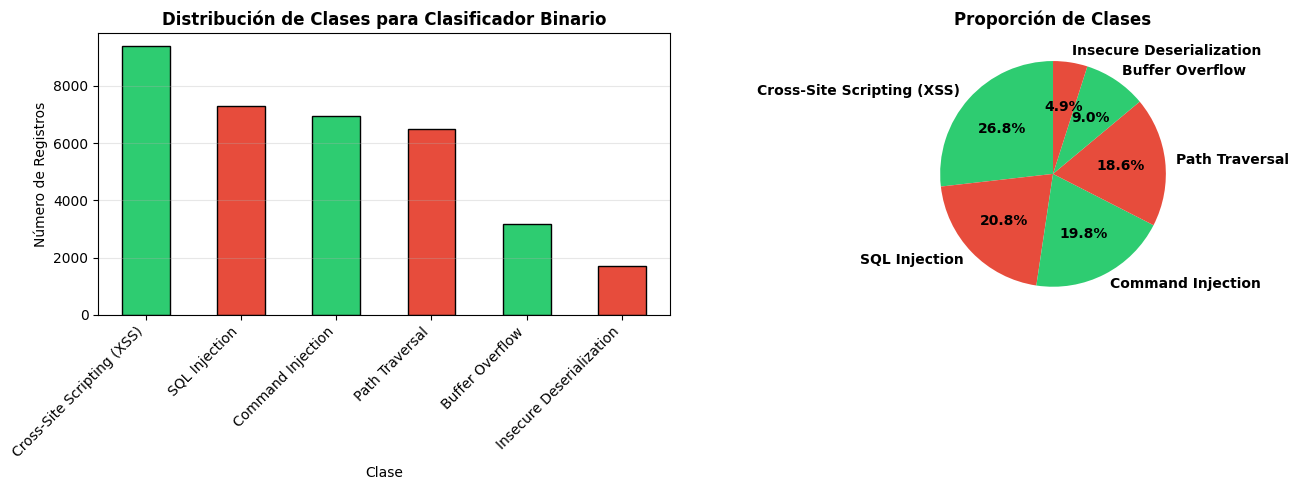


  ✓ ANÁLISIS DE SUFICIENCIA:
    • Total de registros disponibles: 35,000
    • ✓ Suficientes ejemplos (mínimo 100 por clase)
      ✓ Cross-Site Scripting (XSS): 9377 ejemplos
      ✓ SQL Injection: 7297 ejemplos
      ✓ Command Injection: 6947 ejemplos
      ✓ Path Traversal: 6500 ejemplos
      ✓ Buffer Overflow: 3157 ejemplos
      ✓ Insecure Deserialization: 1722 ejemplos


In [23]:
print("=" * 80)
print("VERIFICACIÓN DE BALANCE PARA CLASIFICADOR BINARIO")
print("=" * 80)

# Identificar columna de etiqueta/clase
columnas_label = [col for col in df.columns if 'label' in col.lower() or 'class' in col.lower() or 'type' in col.lower()]

if columnas_label:
    for col_label in columnas_label:
        print(f"\n📊 ANÁLISIS DE BALANCE EN '{col_label}':")
        
        # Contar instancias por clase
        distribucion_clases = df[col_label].value_counts()
        total_registros = len(df)
        
        print(f"\n  Conteo de instancias por clase:")
        for clase, count in distribucion_clases.items():
            porcentaje = (count / total_registros) * 100
            barra = '█' * int(porcentaje / 2)
            print(f"    • {clase}: {count:,} ({porcentaje:.2f}%) {barra}")
        
        # Calcular ratio de desbalance
        if len(distribucion_clases) >= 2:
            clase_mayoritaria = distribucion_clases.iloc[0]
            clase_minoritaria = distribucion_clases.iloc[-1]
            ratio_desbalance = clase_mayoritaria / clase_minoritaria if clase_minoritaria > 0 else float('inf')
            
            print(f"\n  📈 MÉTRICAS DE BALANCE:")
            print(f"    • Ratio clase mayoritaria/minoritaria: {ratio_desbalance:.2f}:1")
            print(f"    • Diferencia absoluta: {clase_mayoritaria - clase_minoritaria:,}")
            
            # Evaluación de balance
            if ratio_desbalance < 1.5:
                balance_status = "✓ EXCELENTE - Datos muy balanceados"
            elif ratio_desbalance < 3:
                balance_status = "✓ BUENO - Datos razonablemente balanceados"
            elif ratio_desbalance < 10:
                balance_status = "⚠️  MODERADO - Existe desbalance, requiere técnicas de balanceo"
            else:
                balance_status = "❌ SEVERO - Desbalance extremo, requiere estrategia especial"
            
            print(f"    • Estado: {balance_status}")
        
        # Visualización
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Gráfico de barras
        distribucion_clases.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'][:len(distribucion_clases)], edgecolor='black')
        ax1.set_title(f'Distribución de Clases para Clasificador Binario', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Número de Registros', fontsize=10)
        ax1.set_xlabel('Clase', fontsize=10)
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax1.grid(axis='y', alpha=0.3)
        
        # Gráfico de pastel con porcentajes
        colores = ['#2ecc71', '#e74c3c'][:len(distribucion_clases)]
        wedges, texts, autotexts = ax2.pie(distribucion_clases.values, labels=distribucion_clases.index, autopct='%1.1f%%',
                colors=colores, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
        ax2.set_title(f'Proporción de Clases', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Análisis de suficiencia
        print(f"\n  ✓ ANÁLISIS DE SUFICIENCIA:")
        print(f"    • Total de registros disponibles: {total_registros:,}")
        
        # Regla general: mínimo 100 ejemplos por clase para ML clásico
        minimo_recomendado = 100
        suficiente = all(count >= minimo_recomendado for count in distribucion_clases.values)
        
        if suficiente:
            print(f"    • ✓ Suficientes ejemplos (mínimo {minimo_recomendado} por clase)")
        else:
            print(f"    • ❌ Insuficientes ejemplos en algunas clases (mínimo {minimo_recomendado} recomendado)")
        
        for clase, count in distribucion_clases.items():
            status = "✓" if count >= minimo_recomendado else "❌"
            print(f"      {status} {clase}: {count} ejemplos")

else:
    print("\n⚠️  No se encontraron columnas de etiqueta/clase obvias.")
    print(f"    Nombres de columnas disponibles: {list(df.columns)}")

## 13. Recomendaciones de Limpieza

In [24]:
print("=" * 80)
print("RECOMENDACIONES DE LIMPIEZA DE DATOS")
print("=" * 80)

# Recopilar hallazgos
hallazgos = []

# 1. Valores nulos
valores_nulos_total = df.isnull().sum().sum()
if valores_nulos_total > 0:
    hallazgos.append({
        'prioridad': 'ALTA',
        'problema': 'Valores nulos detectados',
        'detalles': f'{valores_nulos_total} valores nulos en total',
        'recomendación': 'Considerar eliminar filas con valores nulos críticos o realizar imputación con valores apropiados'
    })

# 2. Registros duplicados
duplicados_total = df.duplicated().sum()
if duplicados_total > 0:
    hallazgos.append({
        'prioridad': 'MEDIA',
        'problema': 'Registros duplicados detectados',
        'detalles': f'{duplicados_total} registros completamente duplicados',
        'recomendación': 'Eliminar registros duplicados manteniendo la primera ocurrencia'
    })

# 3. Registros vacíos
if filas_parcialmente_vacias > 0:
    hallazgos.append({
        'prioridad': 'MEDIA',
        'problema': 'Registros con campos vacíos',
        'detalles': f'{filas_parcialmente_vacias} registros con al menos un campo vacío',
        'recomendación': 'Revisar y eliminar registros con información crítica faltante'
    })

# 4. Código que parece lenguaje natural
if columnas_fix:
    for col_fix in columnas_fix:
        es_natural = df[col_fix].apply(es_probablemente_lenguaje_natural)
        cantidad_natural = es_natural.sum()
        if cantidad_natural > 0:
            hallazgos.append({
                'prioridad': 'MEDIA',
                'problema': f'Explicaciones en lenguaje natural en "{col_fix}"',
                'detalles': f'{cantidad_natural} registros con posible explicación en lugar de código',
                'recomendación': 'Filtrar o revisar manualmente registros donde el "código corregido" no sea código real'
            })

# 5. Registros truncados
if columnas_codigo:
    total_truncados = 0
    for col in columnas_codigo:
        truncados = df[col].apply(es_probablemente_truncado).sum()
        total_truncados += truncados
    
    if total_truncados > 0:
        hallazgos.append({
            'prioridad': 'ALTA',
            'problema': 'Registros potencialmente truncados',
            'detalles': f'{total_truncados} registros potencialmente incompletos',
            'recomendación': 'Eliminar registros truncados o intentar recuperar datos originales'
        })

# 6. Desbalance de clases
columnas_label = [col for col in df.columns if 'label' in col.lower() or 'class' in col.lower() or 'type' in col.lower()]
if columnas_label:
    for col_label in columnas_label:
        distribucion = df[col_label].value_counts()
        if len(distribucion) >= 2:
            ratio = distribucion.iloc[0] / distribucion.iloc[-1] if distribucion.iloc[-1] > 0 else float('inf')
            if ratio > 10:
                hallazgos.append({
                    'prioridad': 'MEDIA',
                    'problema': 'Desbalance severo de clases',
                    'detalles': f'Ratio de desbalance: {ratio:.2f}:1',
                    'recomendación': 'Considerar técnicas de balanceo: sobremuestreo, submuestreo o ajuste de pesos de clases'
                })

# Mostrar recomendaciones
if hallazgos:
    print(f"\n🔍 HALLAZGOS Y RECOMENDACIONES ({len(hallazgos)} items):\n")
    
    # Ordenar por prioridad
    orden_prioridad = {'ALTA': 0, 'MEDIA': 1, 'BAJA': 2}
    hallazgos_ordenados = sorted(hallazgos, key=lambda x: orden_prioridad.get(x['prioridad'], 99))
    
    for idx, hallazgo in enumerate(hallazgos_ordenados, 1):
        print(f"{idx}. [{hallazgo['prioridad']}] {hallazgo['problema']}")
        print(f"   Detalles: {hallazgo['detalles']}")
        print(f"   ➜ {hallazgo['recomendación']}\n")
else:
    print("\n✓ No se detectaron problemas significativos de limpieza en el análisis inicial.")
    print("  El dataset parece estar en buenas condiciones para procesamiento.")

RECOMENDACIONES DE LIMPIEZA DE DATOS

🔍 HALLAZGOS Y RECOMENDACIONES (3 items):

1. [ALTA] Registros potencialmente truncados
   Detalles: 6059 registros potencialmente incompletos
   ➜ Eliminar registros truncados o intentar recuperar datos originales

2. [MEDIA] Registros duplicados detectados
   Detalles: 2517 registros completamente duplicados
   ➜ Eliminar registros duplicados manteniendo la primera ocurrencia

3. [MEDIA] Explicaciones en lenguaje natural en "fixed_code"
   Detalles: 5 registros con posible explicación en lugar de código
   ➜ Filtrar o revisar manualmente registros donde el "código corregido" no sea código real



## 14. Conclusión y Aptitud del Dataset

In [25]:
print("=" * 80)
print("CONCLUSIÓN Y APTITUD DEL DATASET")
print("=" * 80)

# Compilar métricas finales
print("\n📊 RESUMEN EJECUTIVO DEL DATASET:\n")

print(f"{'Métrica':<40} {'Valor':<30}")
print("-" * 70)
print(f"{'Total de registros':<40} {len(df):,}")
print(f"{'Total de características':<40} {df.shape[1]}")
print(f"{'Valores nulos totales':<40} {valores_nulos_total:,} ({(valores_nulos_total/(df.shape[0]*df.shape[1])*100):.2f}%)")
print(f"{'Registros duplicados':<40} {duplicados_total:,} ({(duplicados_total/len(df)*100):.2f}%)")
print(f"{'Registros con campos vacíos':<40} {filas_parcialmente_vacias:,}")

# Evaluación final
print(f"\n🎯 EVALUACIÓN PARA CLASIFICACIÓN BINARIA:\n")

evaluaciones = {
    'Volumen de datos': {
        'valor': len(df),
        'aceptable': len(df) > 500,
        'descripción': 'Cantidad de registros disponibles'
    },
    'Balance de clases': {
        'valor': f'Consultar sección 12',
        'aceptable': True,  # Se evaluará en contexto
        'descripción': 'Distribución entre clases'
    },
    'Calidad de datos': {
        'valor': f'{100 - (valores_nulos_total/(df.shape[0]*df.shape[1])*100):.1f}%',
        'aceptable': (valores_nulos_total/(df.shape[0]*df.shape[1])) < 0.1,
        'descripción': 'Completitud del dataset'
    },
    'Duplicación': {
        'valor': f'{(duplicados_total/len(df)*100):.2f}%',
        'aceptable': (duplicados_total/len(df)) < 0.05,
        'descripción': 'Nivel de registros duplicados'
    }
}

for aspecto, info in evaluaciones.items():
    estado = "✓ ACEPTABLE" if info['aceptable'] else "⚠️  REQUIERE ATENCIÓN"
    print(f"  {aspecto:<35} {info['valor']:<20} {estado}")
    print(f"    └─ {info['descripción']}")

# Conclusión final
print(f"\n{'='*70}")
print("CONCLUSIÓN FINAL")
print(f"{'='*70}\n")

# Calcular puntuación
puntuacion_aceptable = sum([
    len(df) > 500,
    (valores_nulos_total/(df.shape[0]*df.shape[1])) < 0.1,
    (duplicados_total/len(df)) < 0.05
])

if puntuacion_aceptable >= 2:
    conclusion_general = "✓ RECOMENDADO"
    color_recomendacion = "positivo"
    detalles = """
    ✓ El dataset presenta características ADECUADAS para entrenar un modelo de 
      clasificación binaria de vulnerabilidades de código Java.
      
    FACTORES POSITIVOS:
    • Volumen suficiente de datos (>500 registros)
    • Buena completitud de datos (mínimos nulos)
    • Bajo nivel de duplicación
    
    PRÓXIMOS PASOS RECOMENDADOS:
    1. Ejecutar limpieza de datos según recomendaciones en sección 13
    2. Normalizar y preparar características
    3. Dividir en conjuntos de entrenamiento y prueba
    4. Explorar técnicas de balanceo de clases si es necesario
    5. Entrenar modelos de ML clásicos (Random Forest, SVM, XGBoost, etc.)
    6. Evaluar rendimiento con métricas apropiadas (Precisión, Recall, F1-Score)
    """
else:
    conclusion_general = "⚠️  REQUIERE REVISIÓN"
    color_recomendacion = "advertencia"
    detalles = """
    ⚠️  El dataset presenta DEFICIENCIAS que requieren atención antes de 
       entrenar el modelo.
       
    PROBLEMAS DETECTADOS:
    • Datos insuficientes (< 500 registros)
    • Nivel alto de valores nulos (> 10%)
    • Alta tasa de duplicación (> 5%)
    
    ACCIONES REQUERIDAS:
    1. Aplicar estrategias de limpieza más agresivas
    2. Considerar combinar con datasets adicionales
    3. Evaluar técnicas de imputación para datos faltantes
    4. Verificar calidad de la fuente de datos
    """

print(f"ESTADO: {conclusion_general}")
print(f"\n{detalles}")

print(f"\n{'='*70}")
print("FIN DEL ANÁLISIS EXPLORATORIO")
print(f"{'='*70}\n")
print("Generado el:", pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"))
print("\nNota: Este análisis es descriptivo y no realiza transformaciones en los datos.")

CONCLUSIÓN Y APTITUD DEL DATASET

📊 RESUMEN EJECUTIVO DEL DATASET:

Métrica                                  Valor                         
----------------------------------------------------------------------
Total de registros                       35,000
Total de características                 3
Valores nulos totales                    0 (0.00%)
Registros duplicados                     2,517 (7.19%)
Registros con campos vacíos              0

🎯 EVALUACIÓN PARA CLASIFICACIÓN BINARIA:

  Volumen de datos                    35000                ✓ ACEPTABLE
    └─ Cantidad de registros disponibles
  Balance de clases                   Consultar sección 12 ✓ ACEPTABLE
    └─ Distribución entre clases
  Calidad de datos                    100.0%               ✓ ACEPTABLE
    └─ Completitud del dataset
  Duplicación                         7.19%                ⚠️  REQUIERE ATENCIÓN
    └─ Nivel de registros duplicados

CONCLUSIÓN FINAL

ESTADO: ✓ RECOMENDADO


    ✓ El dataset presenta c